Building India baseline histogram...


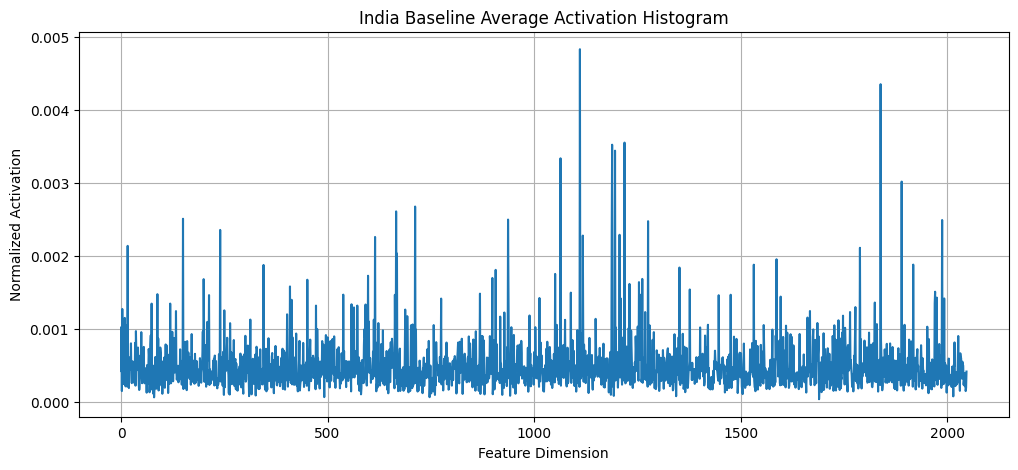

Computing India test KL divergences...
Computing Turkey KL divergences...

FINAL RESULTS
India Test Avg KL vs India Baseline: 0.196496
Turkey Avg KL vs India Baseline:     0.241867


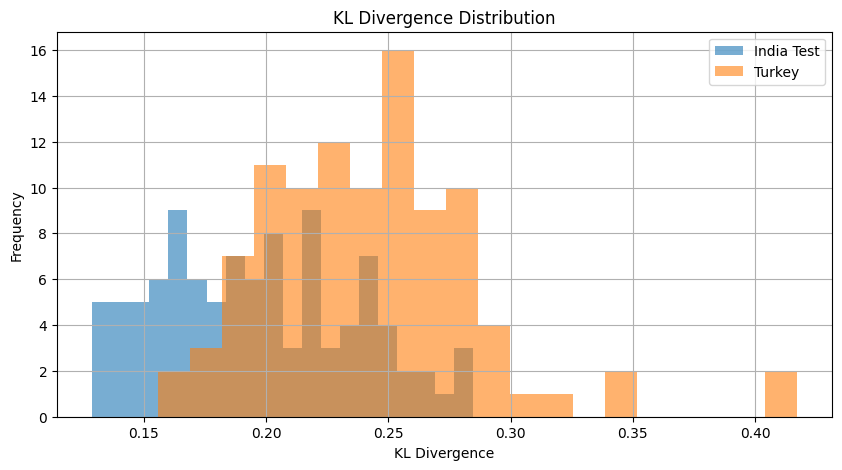

In [7]:
import os
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import numpy as np
from scipy.stats import entropy
import matplotlib.pyplot as plt

############################################################
# CONFIG
############################################################

base_path = "/Users/jaeeponde/Thesis/Roads"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_images_avg = 100
num_images_test = 100

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff", ".webp")


############################################################
# LOAD RESNET50
############################################################

resnet = models.resnet50(pretrained=True).to(device)
resnet.eval()

# Remove final FC layer → Penultimate activations
model = nn.Sequential(*list(resnet.children())[:-1])


############################################################
# IMAGE TRANSFORMS
############################################################

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


############################################################
# HELPER FUNCTIONS
############################################################

def load_image(path):
    return transform(Image.open(path).convert("RGB"))


def get_activation(img_tensor):
    """
    Extract 2048-d penultimate layer activation
    and min-max normalize to [0,1].
    """
    with torch.no_grad():

        feat = model(img_tensor).view(-1)

        feat = (feat - feat.min()) / (feat.max() - feat.min() + 1e-8)

        return feat.cpu().numpy()


############################################################
# LOAD INDIA / TURKEY IMAGE PATHS
############################################################

india_folder = os.path.join(base_path, "India")
turkey_folder = os.path.join(base_path, "Turkey")

india_images = sorted([
    os.path.join(india_folder, f)
    for f in os.listdir(india_folder)
    if f.lower().endswith(image_extensions)
])

turkey_images = sorted([
    os.path.join(turkey_folder, f)
    for f in os.listdir(turkey_folder)
    if f.lower().endswith(image_extensions)
])

assert len(india_images) >= 200, "Need at least 200 India images"
assert len(turkey_images) >= 100, "Need at least 100 Turkey images"


############################################################
# STEP 1 — BUILD INDIA BASELINE HISTOGRAM
############################################################

baseline_feats = []

print("Building India baseline histogram...")

for img_path in india_images[:num_images_avg]:

    img = load_image(img_path).unsqueeze(0).to(device)

    feat = get_activation(img)

    baseline_feats.append(feat)

baseline_feats = np.stack(baseline_feats)

# Average activations across 100 India images
india_baseline_hist = baseline_feats.mean(axis=0)

# Normalize to probability distribution
india_baseline_hist = india_baseline_hist / (india_baseline_hist.sum() + 1e-8)


############################################################
# PLOT INDIA BASELINE HISTOGRAM
############################################################

plt.figure(figsize=(12,5))
plt.plot(india_baseline_hist)
plt.title("India Baseline Average Activation Histogram")
plt.xlabel("Feature Dimension")
plt.ylabel("Normalized Activation")
plt.grid()
plt.show()


############################################################
# STEP 2 — INDIA TEST KL
############################################################

india_kl_values = []

print("Computing India test KL divergences...")

for img_path in india_images[num_images_avg:num_images_avg+num_images_test]:

    img = load_image(img_path).unsqueeze(0).to(device)

    feat = get_activation(img)

    feat = feat / (feat.sum() + 1e-8)

    kl = entropy(feat + 1e-8, india_baseline_hist + 1e-8)

    india_kl_values.append(kl)

india_avg_kl = np.mean(india_kl_values)


############################################################
# STEP 3 — TURKEY KL
############################################################

turkey_kl_values = []

print("Computing Turkey KL divergences...")

for img_path in turkey_images[:num_images_test]:

    img = load_image(img_path).unsqueeze(0).to(device)

    feat = get_activation(img)

    feat = feat / (feat.sum() + 1e-8)

    kl = entropy(feat + 1e-8, india_baseline_hist + 1e-8)

    turkey_kl_values.append(kl)

turkey_avg_kl = np.mean(turkey_kl_values)


############################################################
# PRINT RESULTS
############################################################

print("\n==============================")
print("FINAL RESULTS")
print("==============================")

print(f"India Test Avg KL vs India Baseline: {india_avg_kl:.6f}")
print(f"Turkey Avg KL vs India Baseline:     {turkey_avg_kl:.6f}")


############################################################
# PLOT KL DISTRIBUTIONS
############################################################

plt.figure(figsize=(10,5))

plt.hist(
    india_kl_values,
    bins=20,
    alpha=0.6,
    label="India Test"
)

plt.hist(
    turkey_kl_values,
    bins=20,
    alpha=0.6,
    label="Turkey"
)

plt.legend()
plt.title("KL Divergence Distribution")
plt.xlabel("KL Divergence")
plt.ylabel("Frequency")
plt.grid()

plt.show()